EINGABE G(s) = 1/((0.3*s + 1)*(s + 2))
EINGABE num = [1.0]
EINGABE den = [0.3, 1.6, 2.0]
EINGABE epsilon_max = 0.1
EINGABE t_epsilon_werte = [2.0, 10.0]
EINGABE t_max = 5.0

BERECHNET zeta_min = 0.5912
BERECHNET phi = 53.761 deg
BERECHNET alpha_grenzen = [1.2588, 0.2518]
BERECHNET sigma_grenzen = [-1.2588, -0.2518]
BERECHNET omega_grenzen = +/- 0.6283
BERECHNET sigma_grenze_fuer_Auslegung = -1.2588

AUSGABE empfohlene k-Werte: [0.0, 0.14141414141414144, 0.2828282828282829, 0.42424242424242425, 0.5656565656565657, 0.7070707070707072, 0.8484848484848485, 1.0]
AUSGABE Stabilitaetsgrenze k: None


,k,pole,max_real,min_daempfung,stabil
0,0.000,"[(-3.333333333333335+0j), (-1.9999999999999991...",-2.000,1.000,1.0
1,0.141,"[(-2.6666666666666674+0.1641219879724403j), (-...",-2.667,0.998,1.0
2,0.283,"[(-2.666666666666667+0.7059153620063068j), (-2...",-2.667,0.967,1.0
3,0.424,"[(-2.666666666666667+0.9847319278346613j), (-2...",-2.667,0.938,1.0
4,0.566,"[(-2.666666666666668+1.2004488498380264j), (-2...",-2.667,0.912,1.0
5,0.707,"[(-2.666666666666667+1.382916451727259j), (-2....",-2.667,0.888,1.0
6,0.848,"[(-2.666666666666667+1.5439683882250905j), (-2...",-2.667,0.865,1.0
7,1.000,"[(-2.666666666666667+1.6996731711975945j), (-2...",-2.667,0.843,1.0



AUSGABE Plotdatei: C:\Users\morte\Desktop\Regelungstechnik\Skript\plots\notebook_wurzelort_main.png


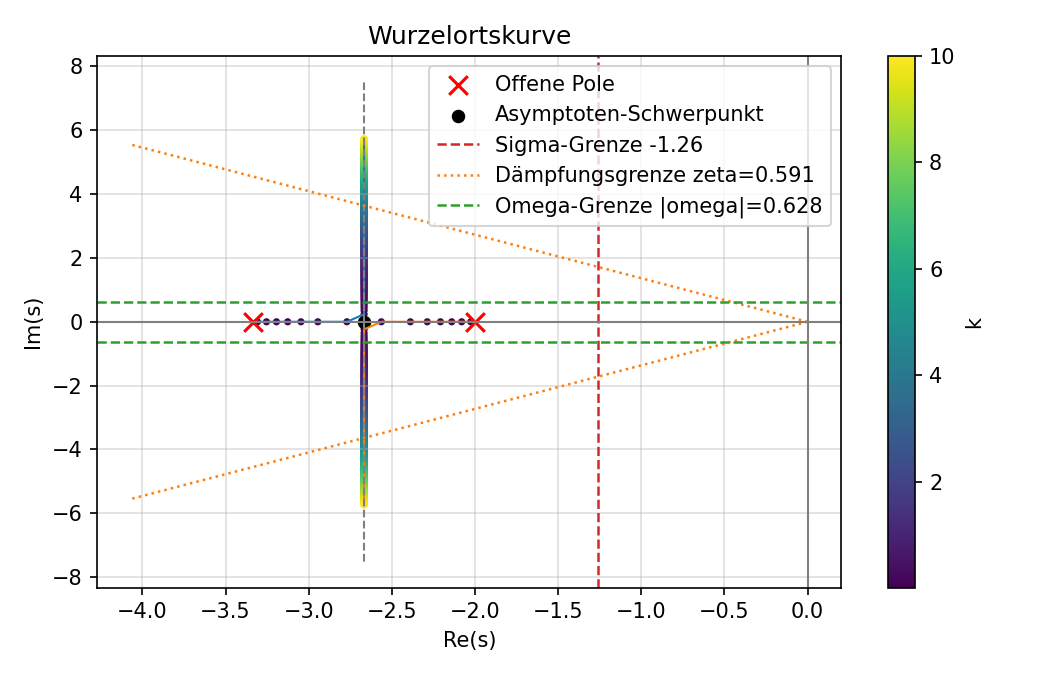

In [8]:
import sys
import importlib
from pathlib import Path
from IPython.display import Image, display
import pandas as pd
import numpy as np
import sympy as sp

projekt_root = Path.cwd()
if not (projekt_root / "regelungstechnik").exists():
    projekt_root = projekt_root.parent
if str(projekt_root) not in sys.path:
    sys.path.insert(0, str(projekt_root))

# Sicherstellen, dass im Notebook die aktuelle Paketversion geladen ist
import regelungstechnik.reglerentwurf as rt_reglerentwurf
import regelungstechnik.plots as rt_plots
importlib.reload(rt_reglerentwurf)
importlib.reload(rt_plots)
from regelungstechnik.reglerentwurf import wurzelortsauslegung
from regelungstechnik.plots import plot_wurzelortskurve

def g_zu_koeffizienten(G_expr):
    s = sp.Symbol("s")
    G_simpl = sp.simplify(G_expr)
    num_expr, den_expr = sp.fraction(G_simpl)
    num = [float(c) for c in sp.Poly(sp.expand(num_expr), s).all_coeffs()]
    den = [float(c) for c in sp.Poly(sp.expand(den_expr), s).all_coeffs()]
    return num, den

def zeta_aus_epsilon_max(epsilon_max):
    ln_eps = np.log(float(epsilon_max))
    return -ln_eps / np.sqrt(np.pi ** 2 + ln_eps ** 2)

def format_wert(x):
    if isinstance(x, (int, float, np.integer, np.floating)):
        return round(float(x), 3)
    if isinstance(x, (complex, np.complexfloating)):
        re = round(float(x.real), 3)
        im = round(float(x.imag), 3)
        return f"{re:.3f}{im:+.3f}j"
    return x

# EINGABE: direkt G(s) angeben
s = sp.Symbol("s")
G = 1 / ((1 + (3 / 10) * s) * (s + 2))

# EINGABE: Entwurfsgrenzen
epsilon_max = 0.1
t_epsilon_werte = [2.0, 10.0]  # Platzhalter fuer Realteilgrenzen
t_max = 5.0  # fuer Imaginaerteilgrenze ueber pi/t_max

if not (0.0 < epsilon_max < 1.0):
    raise ValueError("epsilon_max muss zwischen 0 und 1 liegen.")
if not t_epsilon_werte or any(t <= 0.0 for t in t_epsilon_werte):
    raise ValueError("Alle t_epsilon-Werte muessen groesser als 0 sein.")
if t_max <= 0.0:
    raise ValueError("t_max muss groesser als 0 sein.")

num, den = g_zu_koeffizienten(G)

# Aus epsilon_max folgen zeta und phi
daempfung_min = float(zeta_aus_epsilon_max(epsilon_max))
phi_rad = float(np.arccos(np.clip(daempfung_min, -1.0, 1.0)))
phi_grad = float(np.degrees(phi_rad))

# Realteilgrenze aus: t_e >= ln(epsilon*sqrt(1-zeta^2))/(-alpha) mit alpha = -Re(s) > 0
wurzel_term = float(np.sqrt(max(0.0, 1.0 - daempfung_min ** 2)))
log_term = float(np.log(epsilon_max * wurzel_term))
alpha_grenzen = [float(-log_term / t_eps) for t_eps in t_epsilon_werte]
sigma_grenzen = [float(-alpha) for alpha in alpha_grenzen]

# Imaginaerteilgrenze aus pi/t_max
omega_grenze = float(np.pi / t_max)

# Fuer die k-Auslegung wird die strengere (weiter links liegende) Realteilgrenze genutzt
sigma_grenze_auslegung = float(min(sigma_grenzen))

print("EINGABE G(s) =", sp.simplify(G))
print("EINGABE num =", num)
print("EINGABE den =", den)
print("EINGABE epsilon_max =", epsilon_max)
print("EINGABE t_epsilon_werte =", t_epsilon_werte)
print("EINGABE t_max =", t_max)

print("\nBERECHNET zeta_min =", round(daempfung_min, 4))
print("BERECHNET phi =", round(phi_grad, 3), "deg")
print("BERECHNET alpha_grenzen =", [round(v, 4) for v in alpha_grenzen])
print("BERECHNET sigma_grenzen =", [round(v, 4) for v in sigma_grenzen])
print("BERECHNET omega_grenzen = +/-", round(omega_grenze, 4))
print("BERECHNET sigma_grenze_fuer_Auslegung =", round(sigma_grenze_auslegung, 4))

# Hauptrechnung
res_w = wurzelortsauslegung(
    num, den,
    k_start=0.0,
    k_ende=1.0,
    anzahl_k=100,
    daempfung_min=daempfung_min,
    sigma_grenze=sigma_grenze_auslegung,
)

print("\nAUSGABE empfohlene k-Werte:", res_w["ergebnis"]["k_empfohlen"])
print("AUSGABE Stabilitaetsgrenze k:", res_w["ergebnis"]["k_grenze_stabilitaet"])

df = pd.DataFrame(res_w["ergebnis"]["pole_tabelle"])
df = df.apply(lambda col: col.map(format_wert))
display(df)

res_plot = plot_wurzelortskurve(
    num, den,
    dateiname="notebook_wurzelort_main.png",
    sigma_grenze=sigma_grenze_auslegung,
    daempfung_min=daempfung_min,
    omega_grenze=omega_grenze,
    asymptoten_anzeigen=True,
)

print("\nAUSGABE Plotdatei:", res_plot["plot_pfad"])
if res_plot["plot_pfad"] and Path(res_plot["plot_pfad"]).exists():
    display(Image(filename=res_plot["plot_pfad"]))

## Optionale Beispiele (nur falls noetig)

Diese Zellen sind optional.

Fuer die Klausur ist die erste Berechnungszelle oben der Hauptworkflow.

EINGABE num_ex = [1, -1]
EINGABE den_ex = [4, 5, 2]
AUSGABE empfohlene k-Werte: [0.0, 0.26666666666666666, 0.5333333333333333, 0.8, 1.1333333333333333] ...
AUSGABE Plotdatei: C:\Users\morte\Desktop\Regelungstechnik\Skript\plots\notebook_wurzelort_optional.png


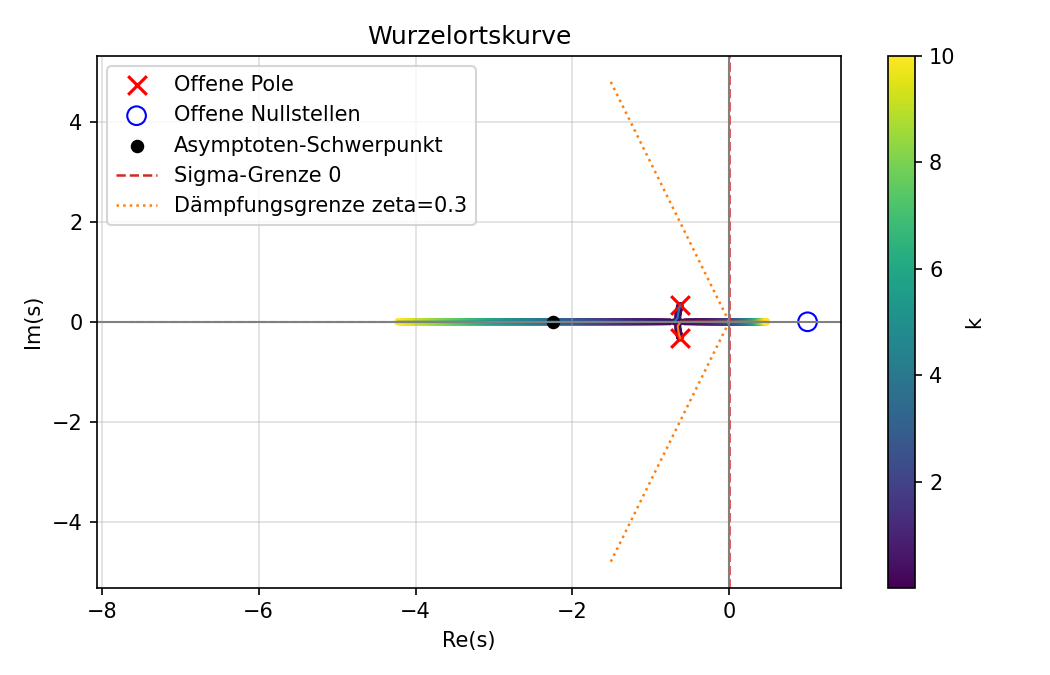

In [9]:
# Optionales Zusatzbeispiel
from pathlib import Path
from IPython.display import Image, display
from regelungstechnik import wurzelortsauslegung, plot_wurzelortskurve

# EINGABE (nur wenn du ein zweites Beispiel brauchst)
num_ex = [1, -1]
den_ex = [4, 5, 2]
print("EINGABE num_ex =", num_ex)
print("EINGABE den_ex =", den_ex)

res_ex = wurzelortsauslegung(
    num_ex, den_ex,
    k_start=0.0,
    k_ende=12.0,
    anzahl_k=181,
    daempfung_min=0.3,
    sigma_grenze=0.0,
 )
print("AUSGABE empfohlene k-Werte:", res_ex["ergebnis"]["k_empfohlen"][:5], "...")

res_plot_ex = plot_wurzelortskurve(
    num_ex, den_ex,
    dateiname="notebook_wurzelort_optional.png",
    sigma_grenze=0.0,
    daempfung_min=0.3,
    asymptoten_anzeigen=True,
 )
print("AUSGABE Plotdatei:", res_plot_ex["plot_pfad"])
if res_plot_ex["plot_pfad"] and Path(res_plot_ex["plot_pfad"]).exists():
    display(Image(filename=res_plot_ex["plot_pfad"]))